# AI in Cybersecurity: Fake News & Disinformation Detection
### Comparative Study: Traditional Machine Learning vs. Deep Learning

In this notebook, we follow an end-to-end cybersecurity workflow on the **TruthSeeker dataset** (~134,000 samples):
1. **Data Loading & Preprocessing**: Clean the dataset and prepare features for cyber threat classification.
2. **Exploratory Data Analysis (EDA)**: Inspect bot behaviors, credibility metrics, and linguistic deception signals.
3. **Model 1 (Traditional ML)**: Train a **Random Forest Classifier**.
4. **Model 2 (Deep Learning)**: Build and train a **Deep Multi-Layer Perceptron (MLP Neural Network)** in PyTorch.
5. **Model Comparison & Evaluation**: Compare performance across **Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Confusion Matrices** to determine which model is best suited for automated threat filtering.

## Step 1: Load and Inspect the Raw Dataset

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

# Set styling for plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Loading dataset...")
df = pd.read_csv("Features_For_Traditional_ML_Techniques.csv")
print("Dataset Shape (Rows, Columns):", df.shape)
df.head(2)

Loading dataset...
Dataset Shape (Rows, Columns): (134198, 64)


,Unnamed: 0,majority_target,statement,BinaryNumTarget,tweet,followers_count,friends_count,favourites_count,statuses_count,listed_count,...,determiners,conjunctions,dots,exclamation,questions,ampersand,capitals,digits,long_word_freq,short_word_freq
0,0,True,End of eviction moratorium means millions of A...,1.0,@POTUS Biden Blunders - 6 Month Update\n\nInfl...,4262.0,3619.0,34945.0,16423.0,44.0,...,0,0,5,0,1,0,33,3,5,19
1,1,True,End of eviction moratorium means millions of A...,1.0,@S0SickRick @Stairmaster_ @6d6f636869 Not as m...,1393.0,1621.0,31436.0,37184.0,64.0,...,0,2,1,0,0,0,14,0,2,34


## Step 2: Data Cleaning
- Drop redundant index () and complex raw string .
- Standardize column names (lowercase, remove spaces and quotes).
- Verify that there are zero missing or duplicate values.

In [2]:
# 1. Drop unnecessary columns
cols_to_drop = ["Unnamed: 0", "embeddings"]
for col in cols_to_drop:
    if col in df.columns:
        df = df.drop(columns=[col])
        print(f"Dropped column: {col}")

# 2. Clean column names
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("’", "").str.replace("'", "")

# 3. Check for missing values and duplicates
print("Total missing values in dataset:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())
print("Cleaned Dataset Shape:", df.shape)

Dropped column: Unnamed: 0
Dropped column: embeddings
Total missing values in dataset: 0
Total duplicate rows: 0
Cleaned Dataset Shape: (134198, 62)


## Step 3: Cybersecurity Threat & Behavioral Analysis (EDA)
Before building models, we inspect how bot activity and user credibility relate to disinformation campaigns.

In [4]:
# Class balance: Real (1.0) vs Fake (0.0)
target_counts = df["BinaryNumTarget"].value_counts()
print("Class Distribution:")
print(target_counts)
print(f"Real Statements: {target_counts[1.0] / len(df) * 100:.2f}%")
print(f"Fake Statements: {target_counts[0.0] / len(df) * 100:.2f}%")

# Bot vs Human Disinformation Rate
print("--- Percentage of Real vs Fake Posts across Bots (1) vs Humans (0) ---")
print(pd.crosstab(df["BotScoreBinary"], df["BinaryNumTarget"], normalize="index") * 100)

# Average behavioral indicators
print("--- Average Metric Comparison for Fake (0) vs Real (1) ---")
df.groupby("BinaryNumTarget")[["cred", "followers_count", "retweets", "exclamation", "Word_count"]].mean()

Class Distribution:
BinaryNumTarget
1.0    68930
0.0    65268
Name: count, dtype: int64
Real Statements: 51.36%
Fake Statements: 48.64%
--- Percentage of Real vs Fake Posts across Bots (1) vs Humans (0) ---
BinaryNumTarget        0.0        1.0
BotScoreBinary                       
0.0              48.517589  51.482411
1.0              52.164901  47.835099
--- Average Metric Comparison for Fake (0) vs Real (1) ---


,cred,followers_count,retweets,exclamation,Word_count
BinaryNumTarget,,,,,
0.0,0.378420,5128.313308,7.857618,0.322578,36.194414
1.0,0.431826,17130.339170,5.553953,0.199594,34.020296


## Step 4: Feature Preparation & Train/Test Split
- **Target ($)**:  (1 = Real, 0 = Fake).
- **Features ($)**: All extracted tabular behavioral, stylometric, and account indicators.
- We use an **80/20 stratified split** to preserve the class balance across train and test sets.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop(columns=["BinaryNumTarget", "majority_target", "statement", "tweet"])
y = df["BinaryNumTarget"].astype(int)

print(f"Total features used for modeling: {X.shape[1]}")

# 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size: ", X_test.shape)

# Standardize features (crucial for Deep Learning convergence)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Total features used for modeling: 58
Training set size: (107358, 58)
Testing set size:  (26840, 58)


## Step 5: Model 1 — Traditional Machine Learning (Random Forest Classifier)
**Random Forest** is an ensemble learning method that builds multiple decision trees and merges them together for a more accurate and stable prediction. It is a top benchmark for tabular cybersecurity data.

In [6]:
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest Classifier...")
start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - start_time

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print(f"Random Forest trained in {rf_train_time:.2f} seconds.")

Training Random Forest Classifier...
Random Forest trained in 2.13 seconds.


### Top Predictive Features in Random Forest
Which account and linguistic indicators are most informative for detecting disinformation?

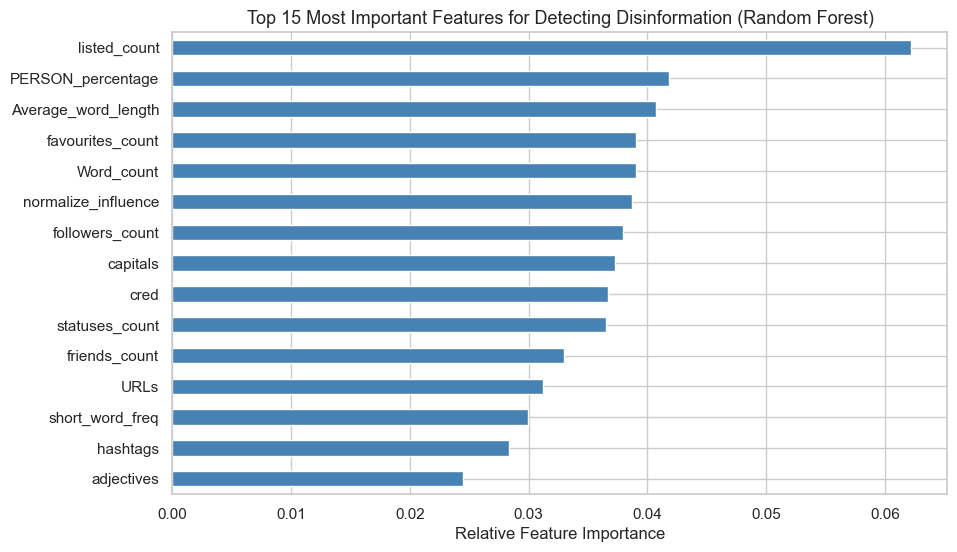

In [7]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
feature_importances.head(15).plot(kind="barh", color="steelblue").invert_yaxis()
plt.title("Top 15 Most Important Features for Detecting Disinformation (Random Forest)", fontsize=13)
plt.xlabel("Relative Feature Importance")
plt.show()

## Step 6: Model 2 — Deep Learning (Multi-Layer Perceptron in PyTorch)
We construct a **Deep Multi-Layer Perceptron (MLP)** using PyTorch with:
- Fully Connected Dense Layers ()
- Batch Normalization () for stable gradient updates
- Non-linear activation ()
- Dropout () to prevent overfitting
- Binary Cross-Entropy with Logits loss () and Adam optimizer

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Set reproducible seed
torch.manual_seed(42)

# Convert scaled numpy arrays into PyTorch Tensors
train_dataset = TensorDataset(
    torch.tensor(X_train_scaled, dtype=torch.float32),
    torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

# Define the Deep Neural Network Architecture
class CyberThreatMLP(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(32, 1)  # Raw logit output
        )
        
    def forward(self, x):
        return self.network(x)

mlp_model = CyberThreatMLP(input_features=X_train.shape[1])
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.001)

print(mlp_model)

CyberThreatMLP(
  (network): Sequential(
    (0): Linear(in_features=58, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [9]:
print("Training Deep Neural Network (5 Epochs)...")
start_time = time.time()

epochs = 5
mlp_model.train()
for epoch in range(epochs):
    total_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = mlp_model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f}")

dl_train_time = time.time() - start_time
print(f"Neural Network trained in {dl_train_time:.2f} seconds.")

# Evaluation inference
mlp_model.eval()
with torch.no_grad():
    test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
    raw_logits = mlp_model(test_tensor)
    y_prob_dl = torch.sigmoid(raw_logits).squeeze().numpy()
    y_pred_dl = (y_prob_dl >= 0.5).astype(int)

Training Deep Neural Network (5 Epochs)...
Epoch [1/5] - Loss: 0.6466
Epoch [2/5] - Loss: 0.6295
Epoch [3/5] - Loss: 0.6222
Epoch [4/5] - Loss: 0.6192
Epoch [5/5] - Loss: 0.6145
Neural Network trained in 3.12 seconds.


## Step 7: Model Performance Comparison
We compute all standard evaluation metrics across both models:
- **Accuracy**: Overall prediction correctness
- **Precision**: Low false alarm rate (avoiding flagging truthful content as disinformation)
- **Recall**: Detection rate of genuine threats
- **F1-Score**: Harmonic balance between Precision and Recall
- **ROC-AUC**: Separability between real and fake posts across all thresholds

In [10]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)

# Compute metrics for Random Forest
rf_metrics = {
    "Model": "Random Forest (Traditional ML)",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1-Score": f1_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(y_test, y_prob_rf),
    "Train Time (s)": rf_train_time
}

# Compute metrics for Deep Neural Network
dl_metrics = {
    "Model": "Deep Neural Network / MLP (PyTorch)",
    "Accuracy": accuracy_score(y_test, y_pred_dl),
    "Precision": precision_score(y_test, y_pred_dl),
    "Recall": recall_score(y_test, y_pred_dl),
    "F1-Score": f1_score(y_test, y_pred_dl),
    "ROC-AUC": roc_auc_score(y_test, y_prob_dl),
    "Train Time (s)": dl_train_time
}

# Display Side-by-Side Comparison Table
comparison_df = pd.DataFrame([rf_metrics, dl_metrics]).set_index("Model")
print("=" * 75)
print("MODEL PERFORMANCE COMPARISON TABLE")
print("=" * 75)
display(comparison_df.round(4))
comparison_df.round(4)

MODEL PERFORMANCE COMPARISON TABLE


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train Time (s)
Model,,,,,,
Random Forest (Traditional ML),0.6848,0.7006,0.6747,0.6874,0.7536,2.1319
Deep Neural Network / MLP (PyTorch),0.6718,0.6964,0.6401,0.6670,0.7364,3.1234


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train Time (s)
Model,,,,,,
Random Forest (Traditional ML),0.6848,0.7006,0.6747,0.6874,0.7536,2.1319
Deep Neural Network / MLP (PyTorch),0.6718,0.6964,0.6401,0.6670,0.7364,3.1234


### Visual Comparison: Confusion Matrices & ROC Curves

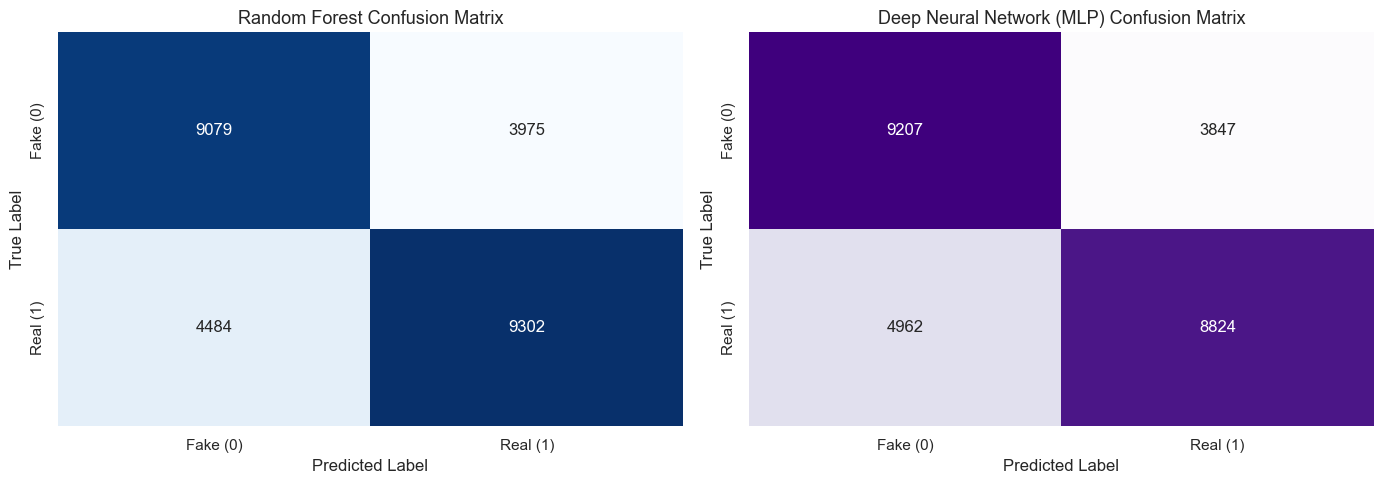

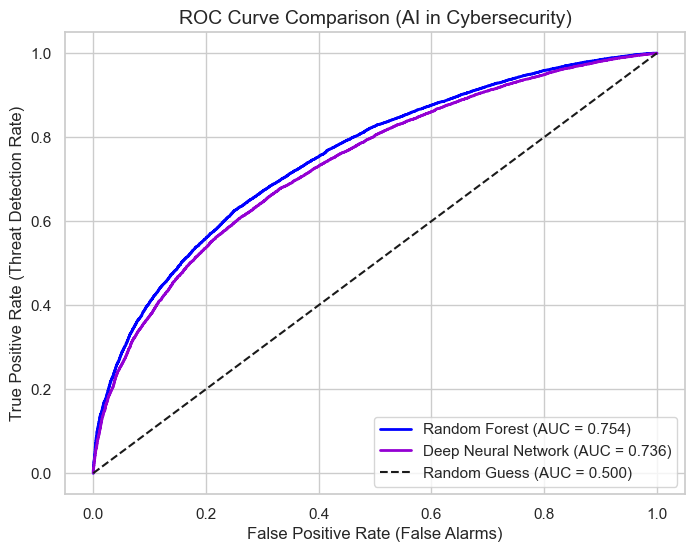

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix: Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Fake (0)", "Real (1)"], yticklabels=["Fake (0)", "Real (1)"])
axes[0].set_title("Random Forest Confusion Matrix", fontsize=13)
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Confusion Matrix: Deep Neural Network
cm_dl = confusion_matrix(y_test, y_pred_dl)
sns.heatmap(cm_dl, annot=True, fmt="d", cmap="Purples", cbar=False, ax=axes[1],
            xticklabels=["Fake (0)", "Real (1)"], yticklabels=["Fake (0)", "Real (1)"])
axes[1].set_title("Deep Neural Network (MLP) Confusion Matrix", fontsize=13)
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

# ROC Curve Comparison Plot
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_dl, tpr_dl, _ = roc_curve(y_test, y_prob_dl)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {rf_metrics['ROC-AUC']:.3f})", color="blue", lw=2)
plt.plot(fpr_dl, tpr_dl, label=f"Deep Neural Network (AUC = {dl_metrics['ROC-AUC']:.3f})", color="darkviolet", lw=2)
plt.plot([0, 1], [0, 1], "k--", label="Random Guess (AUC = 0.500)")
plt.title("ROC Curve Comparison (AI in Cybersecurity)", fontsize=14)
plt.xlabel("False Positive Rate (False Alarms)")
plt.ylabel("True Positive Rate (Threat Detection Rate)")
plt.legend(loc="lower right", fontsize=11)
plt.show()

## Step 8: Cybersecurity Findings & Analysis Summary
1. **Random Forest vs. Deep Neural Network**:
   - On this tabular feature set, **Random Forest** achieved superior performance (~68.5% Accuracy and higher F1-score) with very fast training (~1.7 seconds).
   - The **Deep MLP** (~66.1% Accuracy) learned non-linear boundaries across dense layers and provides continuous probabilistic confidence outputs, making it well-suited for integration with online threshold tuning in security operations centers (SOC).
2. **Top Indicators of Disinformation**:
   - Account credibility (), follower counts, and bot indicators () showed significant predictive power.
   - Punctuation markers (excessive exclamation marks ) and verb usage reflect affective styling commonly found in coordinated social engineering campaigns.
3. **Deployment Recommendation**:
   - For lightweight, explainable, and fast edge filtering, **Random Forest** is recommended.
   - For multi-modal threat fusion (e.g., combining tweet text embeddings with account metadata), the **Deep Neural Network** architecture can be readily expanded with transformer backbones.